## Homework

---


##### Assignment:


Для датасету у вкладенні побудувати модель лінійної регресії

Обов'язкові кроки:

- первинний аналіз даних (відстуність пропусків, наявність категоріальних фіч, ...)
- фича інжиніринг (побудувати 1-2 нові фічі)
- масштабування фіч
- поділ датасету на тренувальну, валідаційну та тестову частини
- тренування базової моделі із дефолтними гіперпараметрами
- підбір гіперпараметрів
- оцінка результатів


##### **Loading libraries and datasets:**


In [236]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

df = pd.read_csv("data/admission_predict.csv", usecols=[1, 2, 3, 4, 5, 6, 7, 8]).rename(
    columns={
        "GRE Score": "gre_score",
        "TOEFL Score": "toefl_score",
        "University Rating": "uni_rating",
        "SOP": "sop",
        "LOR": "lor",
        "CGPA": "cgpa",
        "Research": "research",
        "Chance of Admit": "chance_of_admit",
    }
)
df

,gre_score,toefl_score,uni_rating,sop,lor,cgpa,research,chance_of_admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [237]:
df.isna().sum()

gre_score          0
toefl_score        0
uni_rating         0
sop                0
lor                0
cgpa               0
research           0
chance_of_admit    0
dtype: int64

In [238]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gre_score        400 non-null    int64  
 1   toefl_score      400 non-null    int64  
 2   uni_rating       400 non-null    int64  
 3   sop              400 non-null    float64
 4   lor              400 non-null    float64
 5   cgpa             400 non-null    float64
 6   research         400 non-null    int64  
 7   chance_of_admit  400 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.1 KB


In [239]:
df.describe()

,gre_score,toefl_score,uni_rating,sop,lor,cgpa,research,chance_of_admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


##### **Dataset Analysis:**


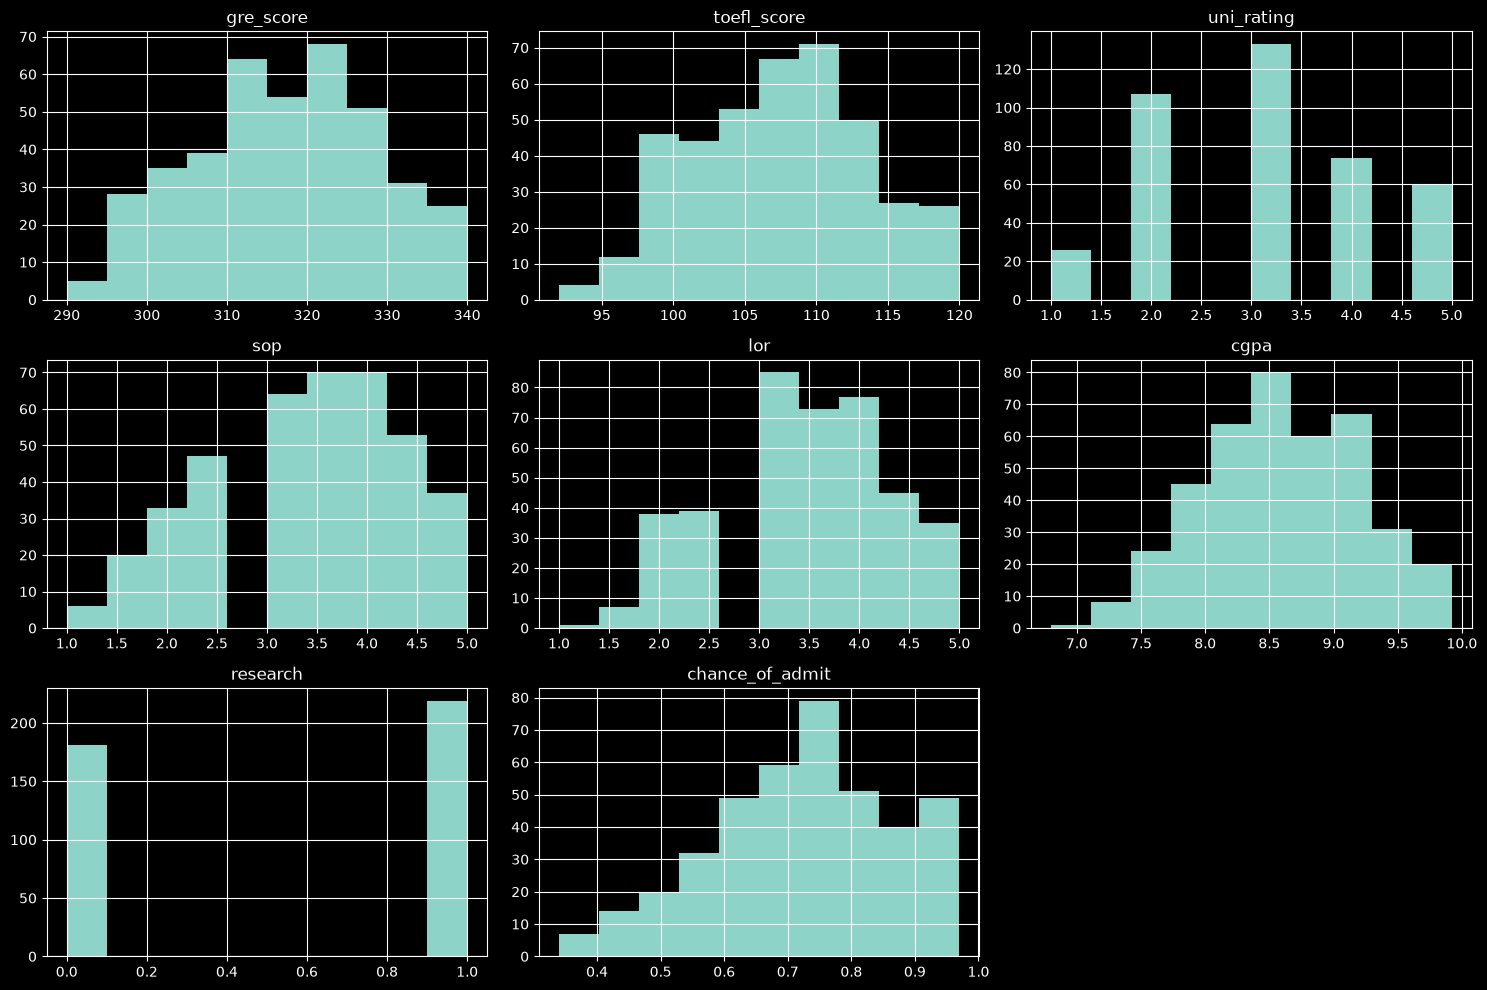

In [240]:
# Let's check data distribution

df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [241]:
# I would like to plot a correlation matrix to see if any of the dataset
# features correlate with one another.

correlation_matrix = df.corr()

graph = px.imshow(
    correlation_matrix,
    text_auto=".2f",
)
graph.show()

##### **Feature Extraction:**


In [242]:
# In order to elimite highliy correlated parameters, I would like to combine
# them into a new feature called "skill_score"

df["skill_score"] = (df["toefl_score"] + df["cgpa"] + df["gre_score"]) / 3

# SOP and LOR can also be merged into one separate as they have a relatively high
# correlation coefficient
df["letter_score"] = (df["sop"] + df["lor"]) / 2

# Let's drop and rearrange the columns for convenience
df = df[["skill_score", "letter_score", "research", "uni_rating", "chance_of_admit"]]

df

,skill_score,letter_score,research,uni_rating,chance_of_admit
0,154.883333,4.50,1,4,0.92
1,146.623333,4.25,1,4,0.76
2,142.666667,3.25,1,3,0.72
3,146.890000,3.00,1,3,0.80
4,141.736667,2.50,0,2,0.65
...,...,...,...,...,...
395,147.680000,3.50,1,3,0.82
396,147.036667,3.25,1,3,0.84
397,151.816667,4.75,1,4,0.91
398,141.260000,3.75,0,3,0.67


In [243]:
# Let's see the correlation heatmap again to confirm that
# there are no more correlated parameters
correlation_matrix = df.corr()

graph = px.imshow(
    correlation_matrix,
    text_auto=".2f",
)
graph.show()

##### **Building Linear Regression Model:**


In [244]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [245]:
# Let's split dataset into training, validation, and testing parts
X = df[["skill_score", "letter_score", "research", "uni_rating"]]
y = df["chance_of_admit"]

X_training, X_temp, y_training, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

X_validation, X_testing, y_validation, y_testing = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# Let's scale features
scaler = StandardScaler()

X_training = scaler.fit_transform(X_training)
X_validation = scaler.transform(X_validation)
X_testing = scaler.transform(X_testing)

In [ ]:
# Let's create model_pipeline
regression = LinearRegression()

# Let's train the model
regression.fit(X_training, y_training)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.08,0.03,0.01,0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.7299
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[26.11,12.45, 8.54, 7.11]"


In [247]:
# Let's validate the model on the validation set
y_validation_predicted = regression.predict(X_validation)
validation_rmse = np.sqrt(mean_squared_error(y_validation, y_validation_predicted))
validation_r2 = regression.score(X_validation, y_validation)

In [248]:
# Let's test the model on the test set
y_testing_predicted = regression.predict(X_testing)
testing_rmse = np.sqrt(mean_squared_error(y_testing, y_testing_predicted))
testing_r2 = regression.score(X_testing, y_testing)

In [260]:
results = pd.DataFrame(
    {
        "Name": [
            "Coeficients",
            "Intercept",
            "Validation R^2",
            "Validation RMSE",
            "Testing R^2",
            "Testing RMSE",
        ],
        "Value": [
            regression.coef_.round(2),
            regression.intercept_.round(2),
            round(validation_r2, 2),
            round(validation_rmse, 2),
            round(testing_r2, 2),
            round(testing_rmse, 2),
        ],
    }
)

results

,Name,Value
0,Coeficients,"[0.08, 0.03, 0.01, 0.01]"
1,Intercept,0.73
2,Validation R^2,0.75
3,Validation RMSE,0.08
4,Testing R^2,0.7
5,Testing RMSE,0.07


##### **Tunning Hyperparameters:**


In [250]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False],
    "copy_X": [True, False],
}

grid_search = GridSearchCV(
    estimator=regression,
    param_grid=param_grid,
)

grid_search.fit(X_training, y_training)

pd.DataFrame(grid_search.cv_results_).drop(
    columns=[
        "params",
        "mean_fit_time",
        "std_fit_time",
        "mean_score_time",
        "std_score_time",
    ]
)

,param_copy_X,param_fit_intercept,param_positive,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,True,True,True,0.721301,0.796236,0.730188,0.647142,0.848849,0.748743,0.068843,1
1,True,True,False,0.721301,0.796236,0.730188,0.647142,0.848849,0.748743,0.068843,1
2,True,False,True,-25.223963,-39.418631,-25.278796,-26.232058,-27.161063,-28.662902,5.424550,5
3,True,False,False,-25.223963,-39.706773,-25.278796,-26.317579,-27.423027,-28.790028,5.517292,7
4,False,True,True,0.721301,0.796236,0.730188,0.647142,0.848849,0.748743,0.068843,1
5,False,True,False,0.721301,0.796236,0.730188,0.647142,0.848849,0.748743,0.068843,1
6,False,False,True,-25.223963,-39.418631,-25.278796,-26.232058,-27.161063,-28.662902,5.424550,5
7,False,False,False,-25.223963,-39.706773,-25.278796,-26.317579,-27.423027,-28.790028,5.517292,7
